# Plot marathon pace

Luc Hens, 21 April 2026.

Given the 5 km splits during a marathon, this script plots the pace per 5 km segment and the average pace. Based on my older R script, converted and expanded with help of Google Gemini. 

       km     split        split_td    segment_time  segment_dist    pace_sec
0   0.000  00:00:00 0 days 00:00:00             NaT           NaN         NaN
1   5.000  00:29:18 0 days 00:29:18 0 days 00:29:18         5.000  351.600000
2  10.000  00:58:53 0 days 00:58:53 0 days 00:29:35         5.000  355.000000
3  15.000  01:29:16 0 days 01:29:16 0 days 00:30:23         5.000  364.600000
4  20.000  01:57:49 0 days 01:57:49 0 days 00:28:33         5.000  342.600000
5  25.000  02:26:03 0 days 02:26:03 0 days 00:28:14         5.000  338.800000
6  30.000  02:53:55 0 days 02:53:55 0 days 00:27:52         5.000  334.400000
7  35.000  03:24:01 0 days 03:24:01 0 days 00:30:06         5.000  361.200000
8  40.000  03:53:10 0 days 03:53:10 0 days 00:29:09         5.000  349.800000
9  42.195  04:06:37 0 days 04:06:37 0 days 00:13:27         2.195  367.653759


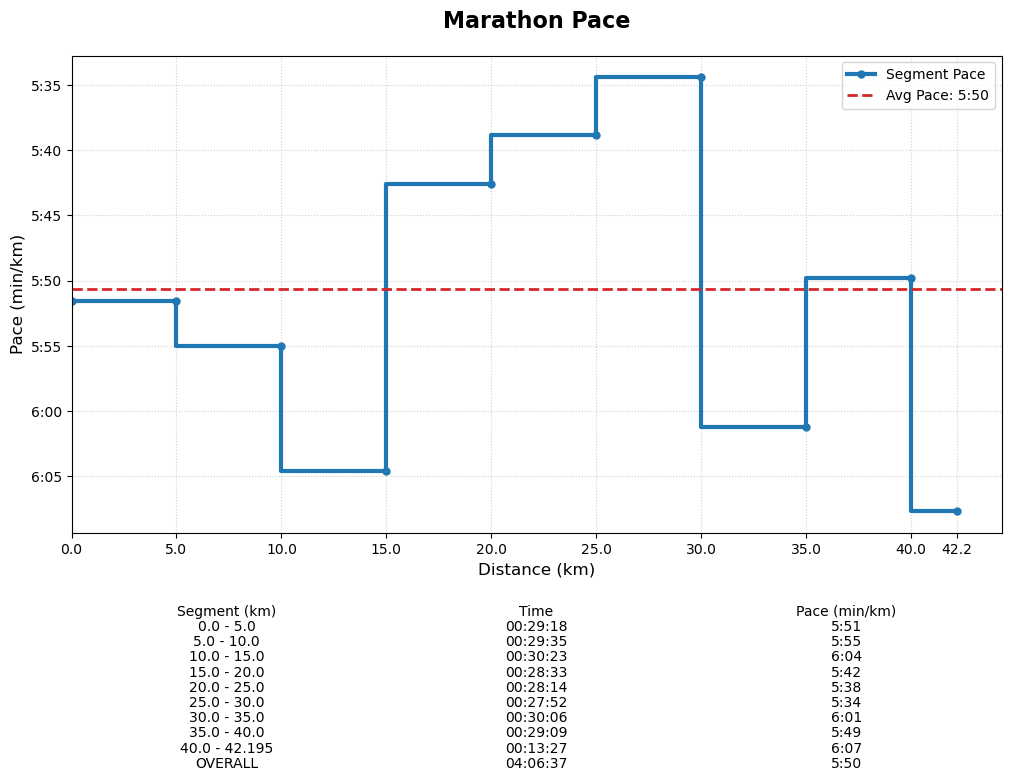


Segment         | Time       | Pace    
----------------------------------------
0.0 - 5.0       | 00:29:18   | 5:51    
5.0 - 10.0      | 00:29:35   | 5:55    
10.0 - 15.0     | 00:30:23   | 6:04    
15.0 - 20.0     | 00:28:33   | 5:42    
20.0 - 25.0     | 00:28:14   | 5:38    
25.0 - 30.0     | 00:27:52   | 5:34    
30.0 - 35.0     | 00:30:06   | 6:01    
35.0 - 40.0     | 00:29:09   | 5:49    
40.0 - 42.195   | 00:13:27   | 6:07    
OVERALL         | 04:06:37   | 5:50    


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# --- 1. CONFIGURATION & DATA ---
distances = [0, 5, 10, 15, 20, 25, 30, 35, 40, 42.195]
# split times for Marathon Leuven, 19 April 2026:
split_times = [
    "00:00:00",
    "00:29:18", # 5k
    "00:58:53", # 10k
    "01:29:16", # 15k
    "01:57:49", # 20k
    "02:26:03", # 25k
    "02:53:55", # 30k
    "03:24:01", # 35k
    "03:53:10", # 40k
    "04:06:37"  # Finish (42.195k)
]

# --- 2. DATA PROCESSING ---
df = pd.DataFrame({'km': distances, 'split': split_times})
df['split_td'] = pd.to_timedelta(df['split'])
df['segment_time'] = df['split_td'].diff()
df['segment_dist'] = df['km'].diff()
df['pace_sec'] = df['segment_time'].dt.total_seconds() / df['segment_dist']

print(df)

avg_pace_sec = df['split_td'].iloc[-1].total_seconds() / 42.195

def format_pace(seconds):
    if pd.isna(seconds): return ""
    return f"{int(seconds // 60)}:{int(seconds % 60):02d}"

# --- 3. VISUALIZATION ---
fig, ax = plt.subplots(figsize=(12, 9))

# Plot Step Graph
paces = df['pace_sec'].dropna().tolist()
ax.step(distances, [paces[0]] + paces, where='pre', color='#1f77b4', 
        linewidth=3, marker='o', markersize=5, label='Segment Pace')

# Add Average Pace Line
ax.axhline(y=avg_pace_sec, color='#d62728', linestyle='--', linewidth=2, 
           label=f'Avg Pace: {format_pace(avg_pace_sec)}')

# Formatting Axes
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format_pace(x)))
ax.invert_yaxis()  # Faster at top
ax.set_xlim(left=0)
ax.set_xticks(distances)
ax.set_title('Marathon Pace', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Distance (km)', fontsize=12)
ax.set_ylabel('Pace (min/km)', fontsize=12)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper right')

# --- 4. EMBEDDED TABLE ---
table_data = []
for i in range(1, len(df)):
    table_data.append([
        f"{df.iloc[i-1]['km']} - {df.iloc[i]['km']}",
        str(df.iloc[i]['segment_time']).split()[-1],
        format_pace(df.iloc[i]['pace_sec'])
    ])
# Add Summary Row
table_data.append(["OVERALL", str(df['split_td'].iloc[-1]).split()[-1], format_pace(avg_pace_sec)])

# Place table at the bottom of the axes
the_table = ax.table(cellText=table_data,
                     colLabels=['Segment (km)', 'Time', 'Pace (min/km)'],
                     loc='bottom',
                     cellLoc='center',
                     bbox=[0.0, -0.5, 1.0, 0.35], # Position adjustment
                     edges='open') 

# Style table
the_table.auto_set_font_size(False)
the_table.set_fontsize(10)
plt.subplots_adjust(bottom=0.35) # Make room for table in the figure

plt.savefig("/Users/luchens/Documents/personal/_running/marathon_leuven_2026/pace.jpg")

plt.show()

# --- 5. CONSOLE OUTPUT ---
print(f"\n{'Segment':<15} | {'Time':<10} | {'Pace':<8}")
print("-" * 40)
for row in table_data:
    print(f"{row[0]:<15} | {row[1]:<10} | {row[2]:<8}")